# Inference Configuration
Specify
- path

In [1]:
path = "../../output/protenn2/v5"


In [2]:
import json
import os.path
import pickle

import torch
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

from src.protenn2.utils import get_train_val_test_paths, get_device, call_domains_list

# get file paths

log_path = os.path.join(path, "log")

label_encoder_path = os.path.join(path, "label_encoder.pkl")
model_path = os.path.join(path, "best_model.pt")
with open(os.path.join(path, "params.json"), "r") as f:
    params = json.load(f)
if "input_folder" not in params:
    raise ValueError("input_folder must be specified")
dataset_path = os.path.join("../../", params["input_folder"])
train_path, val_path, test_path = get_train_val_test_paths(dataset_path)


In [3]:
from src.protenn2.utils import calculate_max_protein_length
from src.protenn2.dataset import CathPredPerResidueDataset, create_protein_collate_fn
from src.protenn2.model import CathPredEnn2
from src.protenn2.analysis.cath_hierarchy_mapper import CATHHierarchyMapper

# Initialize objects

device = get_device()
with open(label_encoder_path, "rb") as f:
    label_encoder: LabelEncoder = pickle.load(f)
num_classes = len(label_encoder.classes_)
max_protein_length = calculate_max_protein_length(dataset_path)

model = CathPredEnn2(num_classes=num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
val_dataset = CathPredPerResidueDataset(val_path, label_encoder=label_encoder,
                                        embedding_dir="../../data/embeddings/protein_embeddings_new")

collate_fn = create_protein_collate_fn(max_protein_length, val_dataset.padding_encoded_id)

val_dataloader = DataLoader(val_dataset, collate_fn=collate_fn)

mapper = CATHHierarchyMapper(label_encoder=label_encoder)

Using MPS (Apple Silicon GPU).
Max protein length: 599
Dataset initialized with 1319 unique proteins.


In [4]:
from src.protenn2.analysis.inference import run_inference

y_true_labels_list, y_pred_confidences_list = run_inference(model=model, dataloader=val_dataloader,
                                                            padding_encoded_id=val_dataset.padding_encoded_id,
                                                            device=device)

Running inference on 1319 proteins...


Inference Progress:  26%|██▌       | 340/1319 [00:00<00:02, 457.59it/s]

Inference Progress: 100%|██████████| 1319/1319 [00:03<00:00, 416.24it/s]

Inference complete. Processed 1319 proteins


# Analysis Configuration

In [5]:
bootstrap_samples = 0
post_process_kwargs = {"reporting_threshold": 0.1}
post_process_func = call_domains_list

In [6]:
from src.protenn2.analysis.metrics import calculate_metrics_for_cath_levels

all_results = calculate_metrics_for_cath_levels(y_true_labels_list=y_true_labels_list,
                                                y_pred_confidences_list=y_pred_confidences_list, mapper=mapper,
                                                bootstrap_samples=bootstrap_samples,
                                                post_process_func=post_process_func,
                                                post_process_kwargs=post_process_kwargs)

---- Computing Metrics for hierarchy: C
----- Accuracy Metrics -----
{'mean': 0.7339822050290136, 'ci_lower': 0.7339822050290136, 'ci_upper': 0.7339822050290136, 'alpha': 0.05}
----- F1 Score Metrics -----
{'mean': 0.7378903573186343, 'ci_lower': 0.7378903573186343, 'ci_upper': 0.7378903573186343, 'alpha': 0.05}
----- Jaccard Score Metrics -----
{'mean': np.float64(0.6329890678212479), 'ci_lower': np.float64(0.6329890678212479), 'ci_upper': np.float64(0.6329890678212479), 'alpha': 0.05}
----- Recall Score Metrics -----
{'mean': 0.7341625215027948, 'ci_lower': 0.7341625215027948, 'ci_upper': 0.7341625215027948, 'alpha': 0.05}
----- Precision Score Metrics -----
{'mean': 0.8207725463645501, 'ci_lower': 0.8207725463645501, 'ci_upper': 0.8207725463645501, 'alpha': 0.05}
----- Accuracy Metrics -----
{'mean': 0.6363357833655706, 'ci_lower': 0.6363357833655706, 'ci_upper': 0.6363357833655706, 'alpha': 0.05}
----- F1 Score Metrics -----
{'mean': 0.6431439250501765, 'ci_lower': 0.64314392505017

# All results

In [7]:
all_results

{'raw_C': {'accuracy': {'mean': 0.7339822050290136,
   'ci_lower': 0.7339822050290136,
   'ci_upper': 0.7339822050290136,
   'alpha': 0.05},
  'f1_score_post': {'mean': 0.7378903573186343,
   'ci_lower': 0.7378903573186343,
   'ci_upper': 0.7378903573186343,
   'alpha': 0.05},
  'jaccard_score': {'mean': np.float64(0.6329890678212479),
   'ci_lower': np.float64(0.6329890678212479),
   'ci_upper': np.float64(0.6329890678212479),
   'alpha': 0.05},
  'recall_score': {'mean': 0.7341625215027948,
   'ci_lower': 0.7341625215027948,
   'ci_upper': 0.7341625215027948,
   'alpha': 0.05},
  'precision_score': {'mean': 0.8207725463645501,
   'ci_lower': 0.8207725463645501,
   'ci_upper': 0.8207725463645501,
   'alpha': 0.05}},
 'post_C': {'accuracy': {'mean': 0.6363357833655706,
   'ci_lower': 0.6363357833655706,
   'ci_upper': 0.6363357833655706,
   'alpha': 0.05},
  'f1_score_post': {'mean': 0.6431439250501765,
   'ci_lower': 0.6431439250501765,
   'ci_upper': 0.6431439250501765,
   'alpha': 0

In [8]:
with open(os.path.join(path, "metrics.json"), "w") as f:
    json.dump(all_results, f)

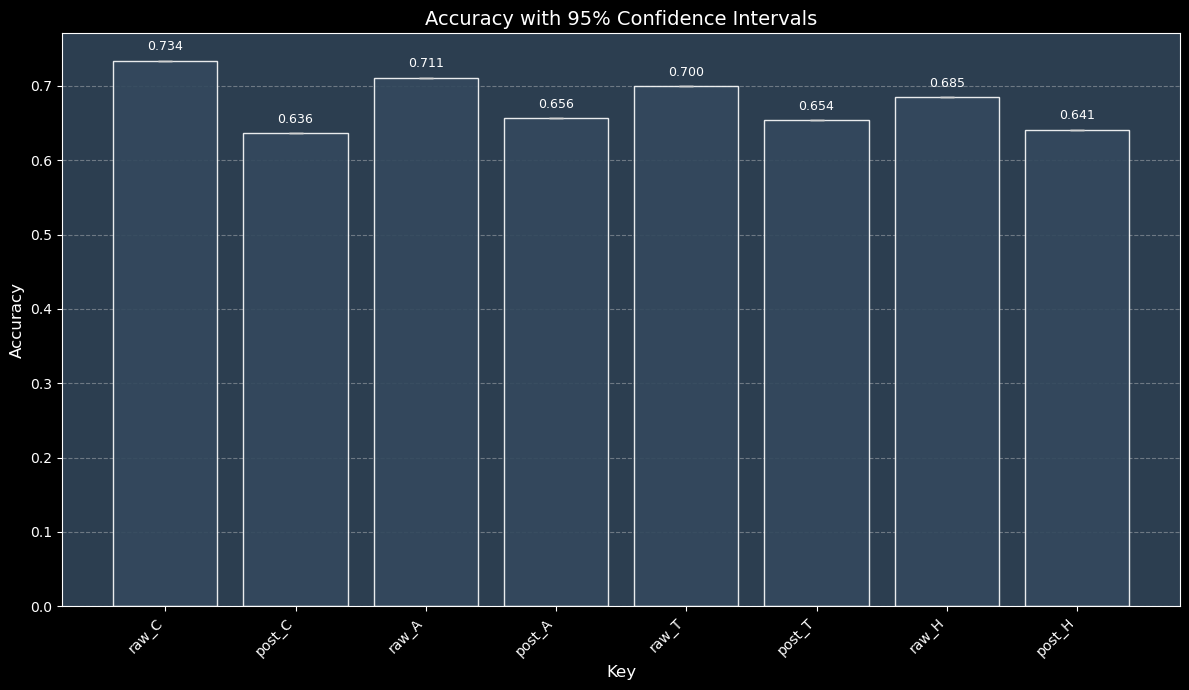

In [9]:
from src.protenn2.analysis.plot import plot_metric_with_ci

plt = plot_metric_with_ci(all_results, "accuracy")
plt.show()

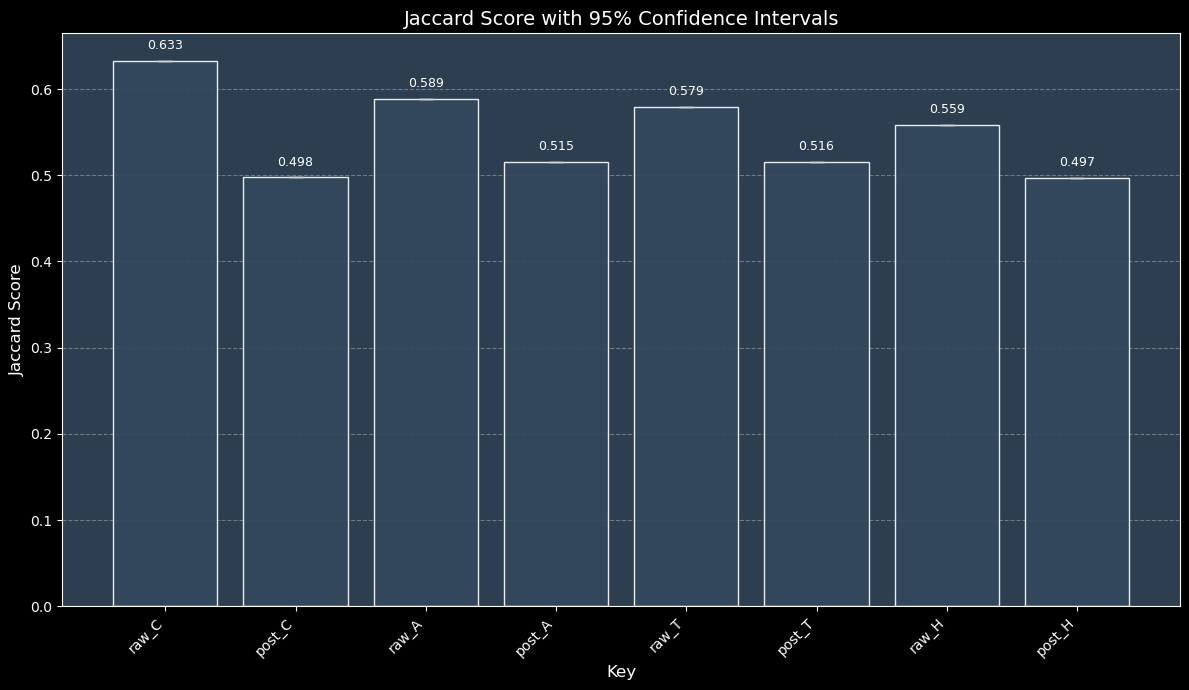

In [10]:
plt = plot_metric_with_ci(all_results, "jaccard_score")
plt.show()